# **Education and Income Analysis:**

In [14]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

In [15]:
data= pd.read_csv("data.csv")

In [16]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [17]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


### **1. Education Level Distribution:**

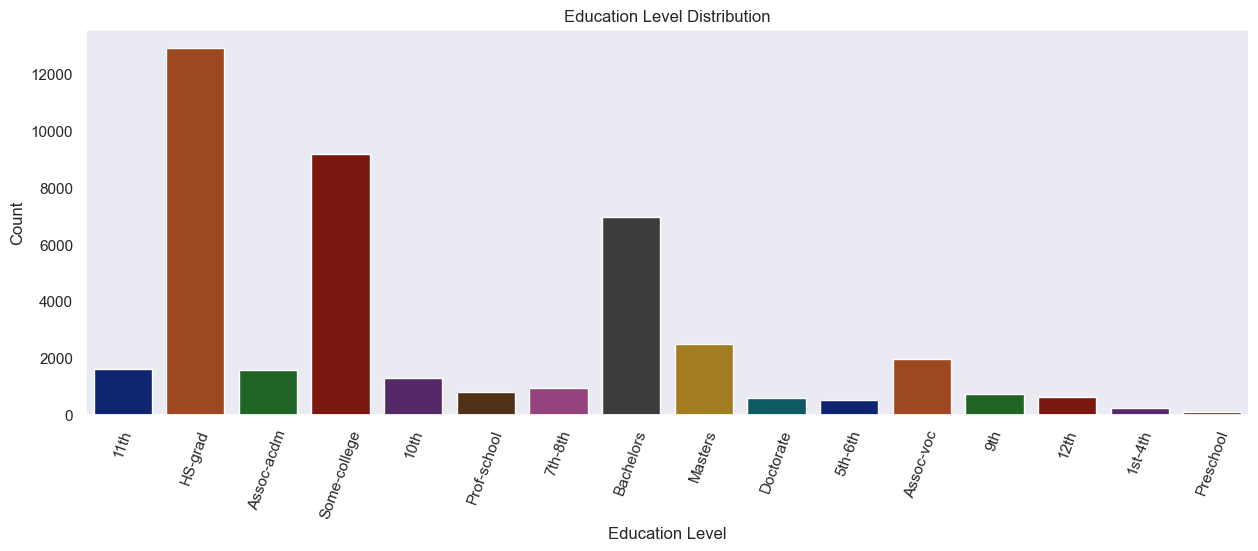

In [18]:
plt.figure(figsize=(15, 5))
sns.countplot(x='education', data=data, palette="dark")
plt.xticks(rotation= 70)
plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

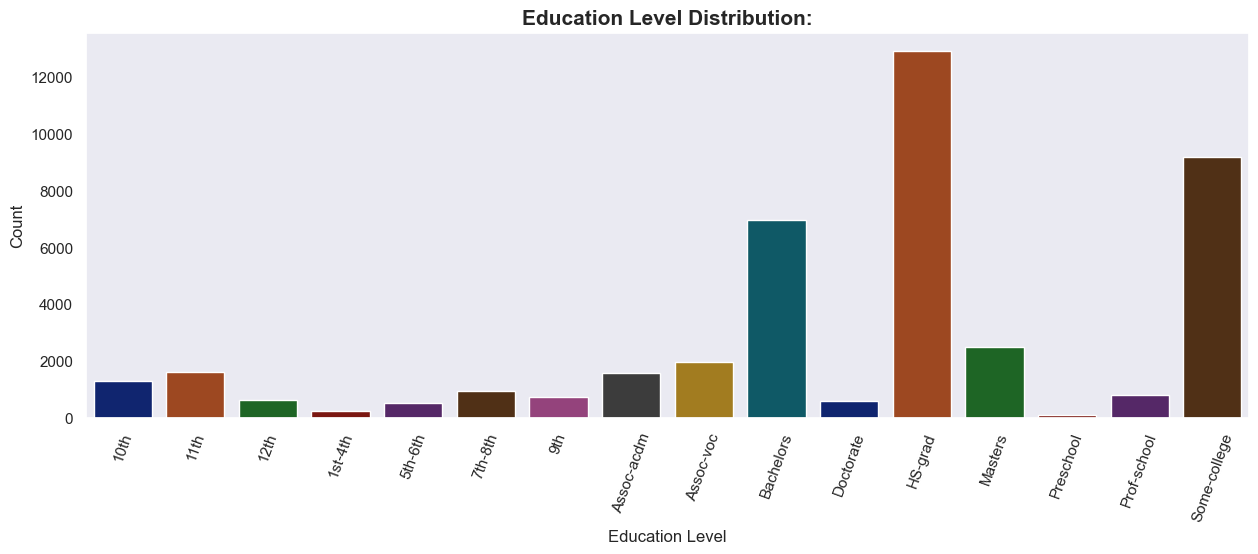

In [19]:
plt.figure(figsize=(15, 5))
ddd= data.groupby("education").size().reset_index()
sns.barplot(data= ddd, x= "education", y= 0, palette= "dark", hue= "education", legend= False)
plt.xticks(rotation= 70)
plt.title('Education Level Distribution:', fontsize= 15, fontweight= "bold")
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

The most common education level is **High School Graduate (HS-grad)**, followed by **Some College** and **Bachelors**. Less frequent levels include **`Doctorate`**, **`Preschool`**, and lower grade levels like **`1st–4th`** and **`5th–6th`**. This indicates that a large portion of the population has at least completed high school, with many pursuing higher education, though fewer reach postgraduate degrees.

---
---
----
----

# **2. Education vs Salary:**

In [20]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [21]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [22]:
data["education"].unique()

array(['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th',
       'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate',
       '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool'],
      dtype=object)

In [23]:
data["salary"].unique()

array(['<=50K', '>50K'], dtype=object)

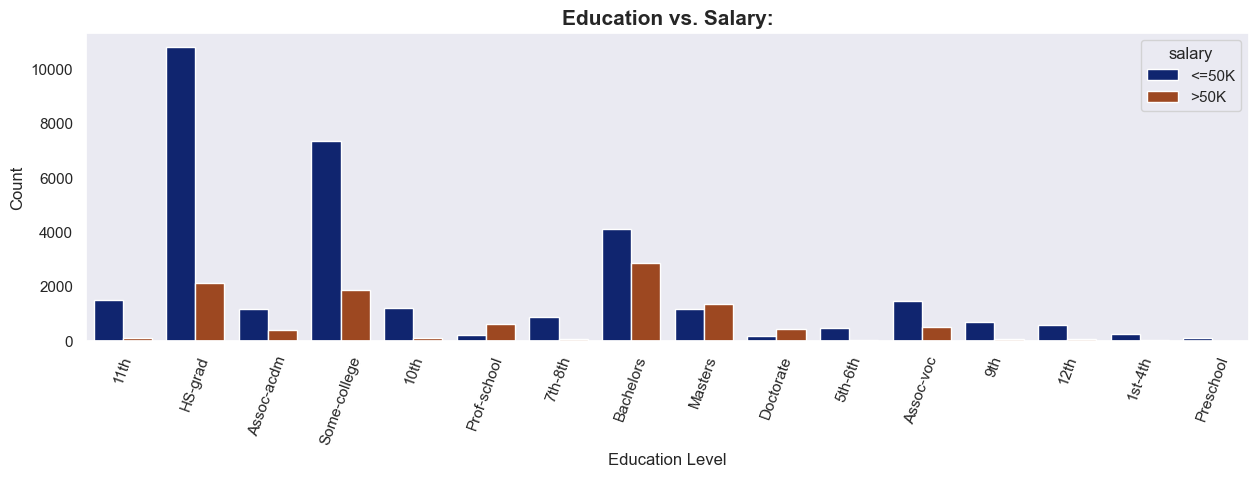

In [24]:
plt.figure(figsize=(15,4))
sns.set_theme(style= "dark", context= "notebook")
sns.countplot(x='education', hue='salary', data=data, palette="dark")
plt.title("Education vs. Salary:", fontsize= 15, fontweight= "bold" )
plt.xlabel("Education Level")   
plt.ylabel("Count")
plt.xticks(rotation= 70)
plt.show()

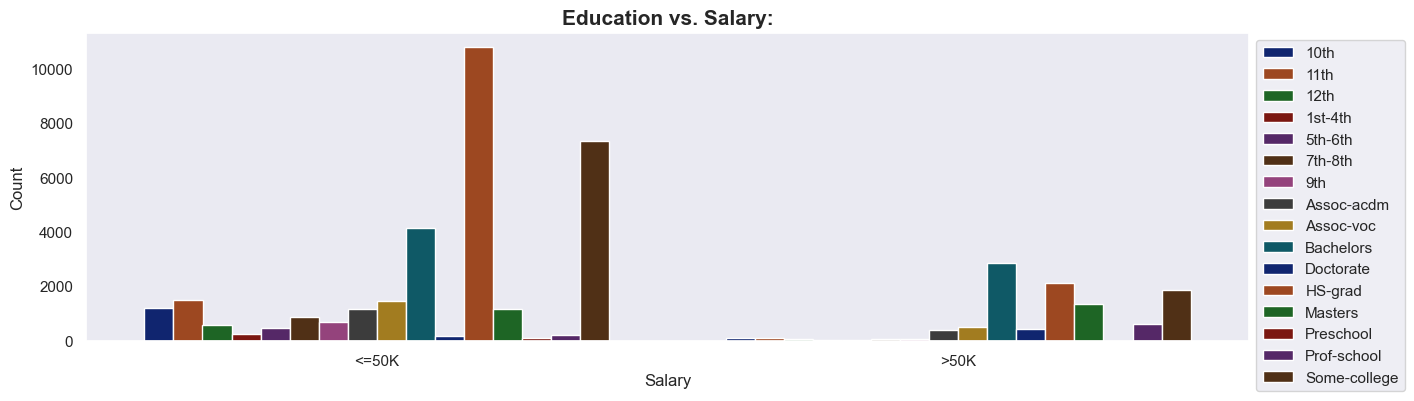

In [25]:
ddaa= data.groupby(by= "education")["salary"].value_counts().reset_index(name= "count")
plt.figure(figsize=(15, 4))
sns.barplot(data= ddaa, hue= "education", y= "count", x= "salary", palette= "dark")
plt.legend(bbox_to_anchor= (1,1))
plt.title("Education vs. Salary:", fontsize= 15, fontweight= "bold")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

---
---
----
-----

### **3. Education-num vs Salary:**

In [26]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [27]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


This is a kind of  classification problem. `education-number` represents the numbers given to educational states of people: 1 was given to class one or equivalent, 2 was ginven to class two or equivalent and goes to number 16 which represents Doctorine degree. 

We have two salary classes:  one for `less or equals to 50k` and other `above 50k`. Lets say `0 is for <=50k` and `1 is for above 50k`. 

**1. Applying Logistic Regression:**

In [30]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Encode the categorical target variable: 

label_encoder = LabelEncoder()
data['salary_encoded'] = label_encoder.fit_transform(data['salary'])  
# Result: '<=50K' → 0, '>50K' → 1

In [32]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary,salary_encoded
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1


In [35]:
# Define feature and target

X = data[['education-num']]  # predictor
y = data['salary_encoded']      # target

In [36]:
X.shape

(42468, 1)

In [37]:
y.shape

(42468,)

In [38]:
# Split into training and test sets:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(33974, 1)
(8494, 1)
(33974,)
(8494,)


In [40]:
# Fit a Logistic Regression model: 
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Make predictions

y_pred = model.predict(X_test)

In [43]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(8494,))

In [57]:
# Evaluate: 
print("_"*70)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_"*70)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("_"*70)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("_"*70)

______________________________________________________________________
Accuracy: 0.7705439133506005
______________________________________________________________________
Confusion Matrix:
 [[6067  314]
 [1635  478]]
______________________________________________________________________
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.95      0.86      6381
           1       0.60      0.23      0.33      2113

    accuracy                           0.77      8494
   macro avg       0.70      0.59      0.60      8494
weighted avg       0.74      0.77      0.73      8494

______________________________________________________________________


**2. Applying DecisionTreeClassifier:**

In [58]:
# Fit the model: 

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Make predictions: 
y_pred = model.predict(X_test)

# Evaluate:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7705439133506005
Confusion Matrix:
 [[6067  314]
 [1635  478]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.95      0.86      6381
           1       0.60      0.23      0.33      2113

    accuracy                           0.77      8494
   macro avg       0.70      0.59      0.60      8494
weighted avg       0.74      0.77      0.73      8494



**3. Applying RandomForestClassifier:**

In [59]:
# Fit the model: 

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Make predictions: 
y_pred = model.predict(X_test)

# Evaluate:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7705439133506005
Confusion Matrix:
 [[6067  314]
 [1635  478]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.95      0.86      6381
           1       0.60      0.23      0.33      2113

    accuracy                           0.77      8494
   macro avg       0.70      0.59      0.60      8494
weighted avg       0.74      0.77      0.73      8494



**4. Applying XGBoostClassifier:**

In [60]:
# Fit the model: 

from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(X_train, y_train)

# Make predictions: 
y_pred = model.predict(X_test)

# Evaluate:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7705439133506005
Confusion Matrix:
 [[6067  314]
 [1635  478]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.95      0.86      6381
           1       0.60      0.23      0.33      2113

    accuracy                           0.77      8494
   macro avg       0.70      0.59      0.60      8494
weighted avg       0.74      0.77      0.73      8494



**1. Overall Accuracy:**

* **77.05%** of the predictions made by the model are correct.
* This might seem good, but it doesn’t tell the full story—especially in **imbalanced classification problems** like this one.


**2. Confusion Matrix Breakdown:**

|                    | Predicted `<=50K` (0)  | Predicted `>50K` (1)  |
| ------------------ | ---------------------- | --------------------- |
| **Actual `<=50K`** | 6067 (True Negatives)  | 314 (False Positives) |
| **Actual `>50K`**  | 1635 (False Negatives) | 478 (True Positives)  |

* **True Negatives (6067)**: People earning `<=50K` correctly identified.
* **False Positives (314)**: People earning `<=50K` wrongly predicted as `>50K`.
* **False Negatives (1635)**: People earning `>50K` wrongly predicted as `<=50K`. **This is a big problem.**
* **True Positives (478)**: People earning `>50K` correctly identified.


**3. Precision, Recall, F1-Score (Per Class):**

**Class 0 (`<=50K`):**

* **Precision: 0.79** → Of all people predicted as `<=50K`, **79% were correct**.
* **Recall: 0.95** → Of all people who actually earn `<=50K`, **95% were correctly caught**.
* **F1-score: 0.86** → Balance between precision and recall is strong.

**Class 1 (`>50K`):**

* **Precision: 0.60** → Of all predicted `>50K`, only **60% were actually correct**.
* **Recall: 0.23** → Of all actual `>50K` earners, only **23% were caught**.
* **F1-score: 0.33** → The model **struggles badly** to identify high earners.

**4. Macro vs Weighted Averages:**

* **Macro Average**: Treats both classes equally → Low (precision 0.70, recall 0.59).
* **Weighted Average**: Takes class imbalance into account → Better looking (but class 1 is still weak).

**5. What's the Issue?**

The model is **biased towards the majority class (`<=50K`)**, because: We have many more people earning `<=50K` than `>50K` in our dataset. So it plays "safe" and tends to guess `<=50K` more often.

**6. What We Can Do to Improve Class 1 Detection:**

   1. **Balance the data** using:
   * `SMOTE` (oversampling the minority class)
   * `RandomUnderSampler` (undersampling the majority class)
   2. **Add more features**, not just `education-number`. Salary depends on many things: Occupation, Work hours, Age, Education type etc. 
   3. **Try model tuning** (e.g. grid search, hyperparameter tuning)

**7. Summary:**

* Our model is good at predicting low salary (`<=50K`), but very poor at predicting high salary (`>50K`).
* The problem is most likely **class imbalance** and **lack of features**.
* Fixing those two things can lead to better balance and more meaningful predictions.

---
---
---
---

### **4. Average Capital Gain by Education:**

In [61]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary',
       'salary_encoded'],
      dtype='object')

In [62]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary,salary_encoded
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1


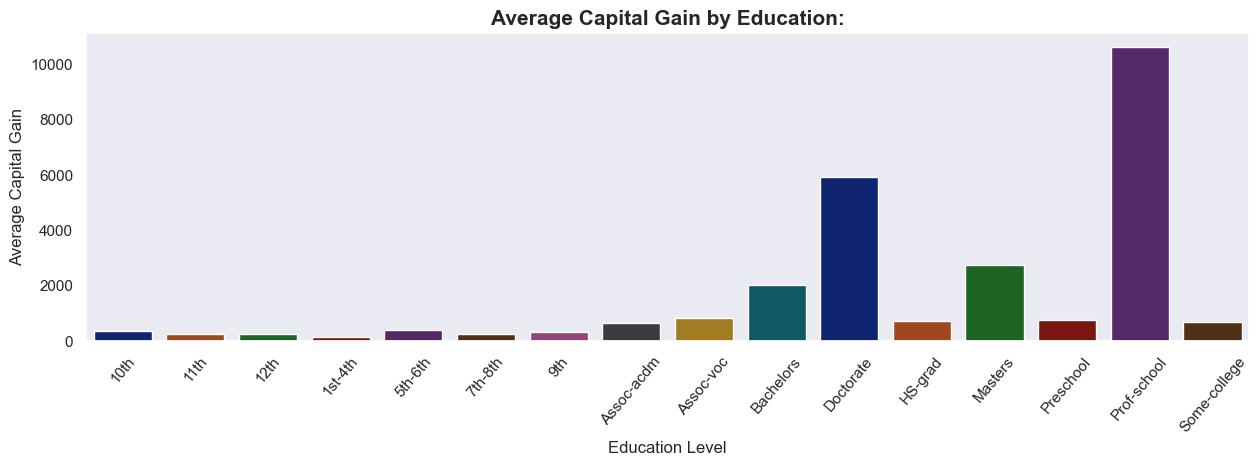

In [71]:
plt.figure(figsize=(15, 4))
sns.set_theme(style= "dark", context= "notebook")
daa= data.groupby(by= "education")["capital-gain"].mean().reset_index()
sns.barplot(data= daa, x= "education", y= "capital-gain", palette= "dark")
plt.xticks(rotation= 50)
plt.title("Average Capital Gain by Education:", fontsize= 15, fontweight= "bold")
plt.xlabel("Education Level")
plt.ylabel("Average Capital Gain")
plt.show()

The plot shows the average capital gain associated with different education levels. Individuals with `"Prof-school"` and `"Doctorate"` degrees experience the highest average capital gains, exceeding 10,000 and around 5,000, respectively. In contrast, those with lower education levels, such as `"9th"` and `"10th"` grade, report minimal capital gains. This indicates a clear correlation between higher education and increased capital gains, highlighting the financial benefits of advanced education.

----
---
---
---

### **5. Education vs Hours Worked:**

In [72]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary',
       'salary_encoded'],
      dtype='object')

In [73]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary,salary_encoded
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1


In [76]:
sss= data.groupby(by= "education")["hours-per-week"].mean().reset_index().sort_values(by= "hours-per-week", ascending= False)
sss

,education,hours-per-week
14,Prof-school,47.528905
10,Doctorate,46.562500
12,Masters,43.501801
9,Bachelors,42.458016
8,Assoc-voc,41.699643
7,Assoc-acdm,40.816379
11,HS-grad,40.740228
15,Some-college,39.376905
5,7th-8th,38.955961
4,5th-6th,38.877510


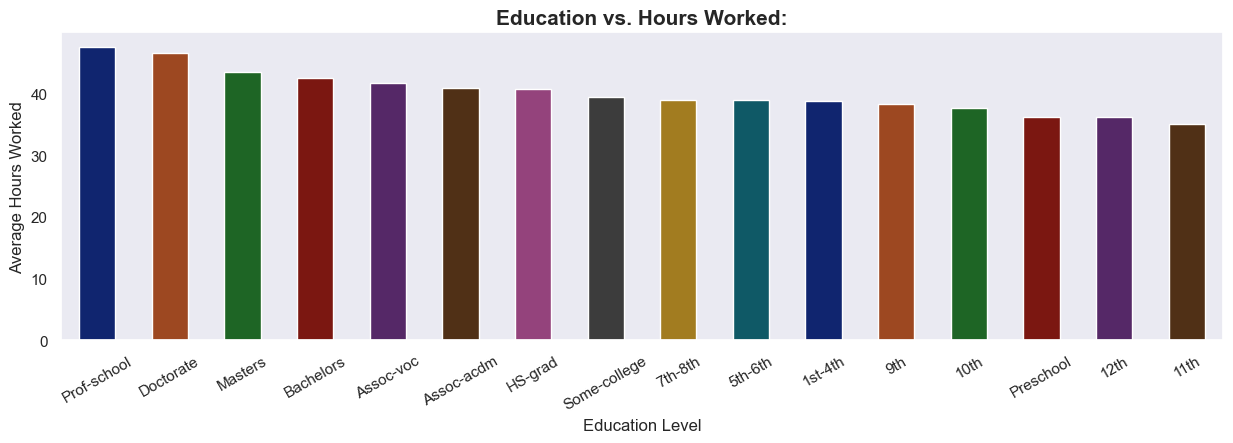

In [79]:
plt.figure(figsize=(15, 4))
sns.set_theme(style= "dark", context= "notebook")
sns.barplot(data= sss, x= "education", y= "hours-per-week", palette= "dark", hue= "education", legend= False, width= 0.5)
plt.xticks(rotation= 30)
plt.xlabel("Education Level")
plt.ylabel("Average Hours Worked")
plt.title("Education vs. Hours Worked:", fontsize= 15, fontweight= "bold")  
plt.show()

The plot shows the average hours worked by individuals at different education levels, revealing that those with higher education, such as `"Prof-school"` and `"Doctorate,"` generally work more hours compared to those with lower education levels. This suggests that advanced degrees may lead to more demanding jobs that require longer hours.

The traditional belief that more education results in working less is challenged here, as the data indicates that higher education can correlate with increased work hours, possibly due to the responsibilities that come with higher-level positions.

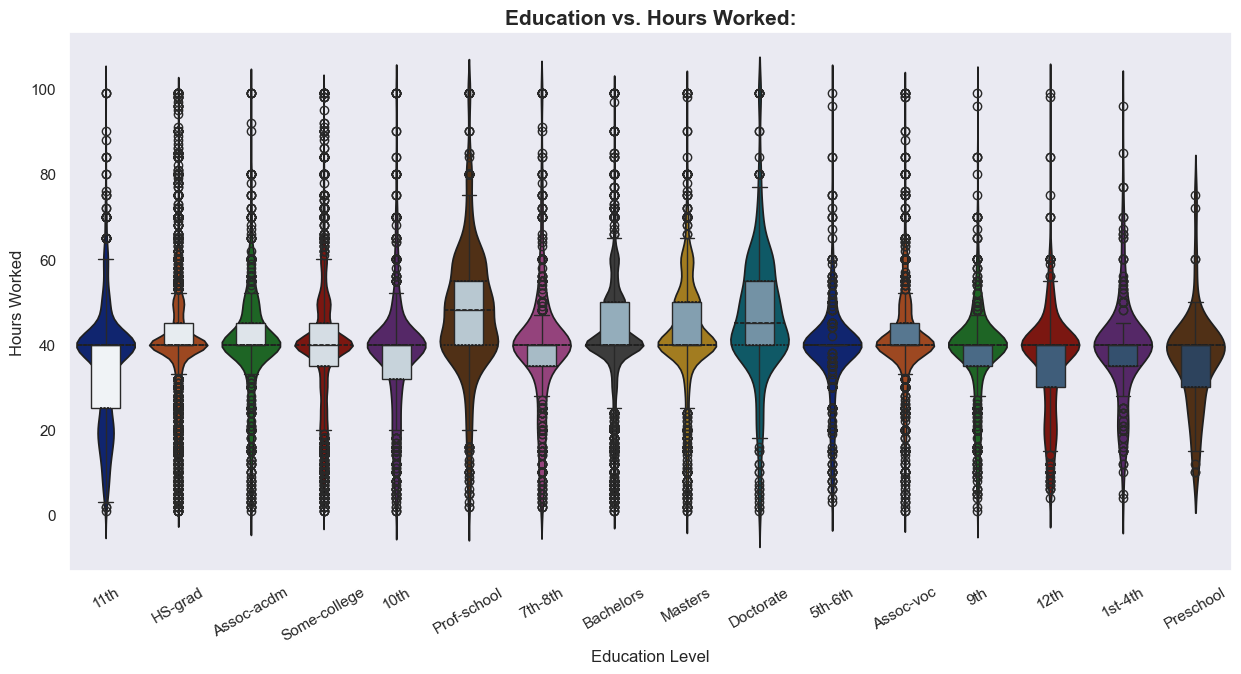

In [94]:
plt.figure(figsize=(15, 7))
sns.set_theme(style= "dark", context= "notebook")
sns.boxplot(data= data, x= "education", y= "hours-per-week", palette= "Blues", hue= "education", legend= False, width= 0.4, saturation=0.4)
sns.violinplot(data= data, x= "education", y= "hours-per-week", palette= "dark", inner= "quartile")
plt.xticks(rotation= 30)
plt.xlabel("Education Level")
plt.ylabel("Hours Worked")
plt.title("Education vs. Hours Worked:", fontsize= 15, fontweight= "bold")
plt.show()

The plot presents a violin chart showing the distribution of hours worked across various education levels. It indicates that individuals with lower education, such as "11th" and "Preschool," tend to work fewer hours, while those with higher education levels, like "Doctorate" and "Prof-school," exhibit a wider range of hours worked, with some working significantly more. The distribution also suggests that while higher education can lead to higher hours worked, there's substantial variability, indicating some individuals in advanced roles may work fewer hours, reflecting diverse job conditions and roles within each educational category.